### DS 3026 Final Project - Section 6

# Part 6: Predictive Modeling 

**Predictive Question:** Can we predict whether the home team will win an NBA game? 

**Target Variable:** $Y ∈ {0, 1\\}$, where Y=1 if the home team wins and 0 otherwise 

**Model**: We fit a logistic regression model to predict the probability that the home team wins based on available features.

**Evaluation Metric:** We initially utilized `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, and `roc_auc_score` to evaluate the model on a test set. Then we moved on to more specialized information on the model like `model.score` and `confusion_matrix` to visualize results.

In [1]:
# imports 
import pandas as pd 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
# load game data 
games = pd.read_csv('./data/game_df.csv')

## 1 - Train/test Split

Before actually doing the train/test split, we need to clean up the columns to make them more suitable for predictive modeling. First, we need to drop columns that are irrelevant. We are also dropping the points columns because they are direct giveaways to the model for which team won each game.

In [3]:
# dropping columns that are not needed for predictive modeling
cols_drop = ['min', 'team_abbreviation_home', 'team_abbreviation_away', 'team_nickname_home', 'team_nickname_away', 
             'team_city_name_home', 'team_city_name_away', 'pts_qtr1_home', 'pts_qtr2_home', 'pts_qtr3_home', 'pts_qtr4_home',
             'pts_ot1_home', 'pts_ot2_home', 'pts_ot3_home', 'pts_ot4_home', 'pts_ot5_home', 'pts_ot6_home', 'pts_ot7_home', 
             'pts_ot8_home', 'pts_ot9_home', 'pts_ot10_home', 'pts_qtr1_away', 'pts_qtr2_away', 'pts_qtr3_away', 'pts_qtr4_away', 
             'pts_ot1_away', 'pts_ot2_away', 'pts_ot3_away', 'pts_ot4_away', 'pts_ot5_away', 'pts_ot6_away', 'pts_ot7_away', 
             'pts_ot8_away', 'pts_ot9_away', 'pts_ot10_away', 'largest_lead_home', 'largest_lead_away', 'lead_changes', 'times_tied', 
             'plus_minus_home', 'plus_minus_away', 'video_available_home', 'video_available_away', 'season_type', 'team_rebounds_home',
             'team_rebounds_away', 'team_turnovers_home', 'total_turnovers_home', 'team_turnovers_away', 'total_turnovers_away', 
             'matchup_home', 'matchup_away', 'game_date', 'team_wins_losses_home', 'team_wins_losses_away']
games2 = games.drop(columns=cols_drop)
games2.columns

Index(['season_id', 'team_id_home', 'team_name_home', 'game_id', 'wl_home',
       'fgm_home', 'fga_home', 'fg_pct_home', 'fg3m_home', 'fg3a_home',
       'fg3_pct_home', 'ftm_home', 'fta_home', 'ft_pct_home', 'oreb_home',
       'dreb_home', 'reb_home', 'ast_home', 'stl_home', 'blk_home', 'tov_home',
       'pf_home', 'pts_home', 'team_id_away', 'team_name_away', 'wl_away',
       'fgm_away', 'fga_away', 'fg_pct_away', 'fg3m_away', 'fg3a_away',
       'fg3_pct_away', 'ftm_away', 'fta_away', 'ft_pct_away', 'oreb_away',
       'dreb_away', 'reb_away', 'ast_away', 'stl_away', 'blk_away', 'tov_away',
       'pf_away', 'pts_away', 'game_date_est', 'game_sequence',
       'team_city_home', 'pts_paint_home', 'pts_2nd_chance_home',
       'pts_fb_home', 'pts_off_to_home', 'team_city_away', 'pts_paint_away',
       'pts_2nd_chance_away', 'pts_fb_away', 'pts_off_to_away'],
      dtype='object')

In [4]:
# change 'wl_home' to be numeric, with W = 1 and L = 0
games2['wl_home'] = games2['wl_home'].map({'W': 1, 'L': 0})

Here, we are creating rolling average columns for the different stats. This means calculating the averages from the previous games, which are then updated after each new game. Doing so helps the model learn about previous patterns for the teams to help predict about the next game.

In [5]:
# columns that need to be transformed into rolling averages 
stat_home_cols = ['fgm_home', 'fga_home', 'fg_pct_home', 'fg3m_home', 'fg3a_home', 'fg3_pct_home', 
             'ftm_home', 'fta_home', 'ft_pct_home', 'oreb_home', 'dreb_home', 'reb_home', 
             'ast_home', 'stl_home', 'blk_home', 'tov_home', 'pf_home', 'pts_home',
             'pts_paint_home', 'pts_2nd_chance_home', 'pts_fb_home', 'pts_off_to_home']

stat_away_cols = ['fgm_away', 'fga_away', 'fg_pct_away', 'fg3m_away', 'fg3a_away', 'fg3_pct_away',
             'ftm_away', 'fta_away', 'ft_pct_away', 'oreb_away', 'dreb_away', 'reb_away',
             'ast_away', 'stl_away', 'blk_away', 'tov_away', 'pf_away', 'pts_away', 
             'pts_paint_away', 'pts_2nd_chance_away', 'pts_fb_away', 'pts_off_to_away']

In [6]:
# for each stat column, create a new column that is the rolling average for the last 10 games
# group by each team_id && drop the original stat column 
# home columns 
for col in stat_home_cols:
    games2[col + '_avg_10'] = games2.groupby('team_id_home')[col].transform(lambda x: x.rolling(10, min_periods=1).mean())
    games2 = games2.drop(columns=[col])

# away columns 
for col in stat_away_cols:
    games2[col + '_avg_10'] = games2.groupby('team_id_away')[col].transform(lambda x: x.rolling(10, min_periods=1).mean())
    games2 = games2.drop(columns=[col])

# verify new columns
games2.columns 

Index(['season_id', 'team_id_home', 'team_name_home', 'game_id', 'wl_home',
       'team_id_away', 'team_name_away', 'wl_away', 'game_date_est',
       'game_sequence', 'team_city_home', 'team_city_away', 'fgm_home_avg_10',
       'fga_home_avg_10', 'fg_pct_home_avg_10', 'fg3m_home_avg_10',
       'fg3a_home_avg_10', 'fg3_pct_home_avg_10', 'ftm_home_avg_10',
       'fta_home_avg_10', 'ft_pct_home_avg_10', 'oreb_home_avg_10',
       'dreb_home_avg_10', 'reb_home_avg_10', 'ast_home_avg_10',
       'stl_home_avg_10', 'blk_home_avg_10', 'tov_home_avg_10',
       'pf_home_avg_10', 'pts_home_avg_10', 'pts_paint_home_avg_10',
       'pts_2nd_chance_home_avg_10', 'pts_fb_home_avg_10',
       'pts_off_to_home_avg_10', 'fgm_away_avg_10', 'fga_away_avg_10',
       'fg_pct_away_avg_10', 'fg3m_away_avg_10', 'fg3a_away_avg_10',
       'fg3_pct_away_avg_10', 'ftm_away_avg_10', 'fta_away_avg_10',
       'ft_pct_away_avg_10', 'oreb_away_avg_10', 'dreb_away_avg_10',
       'reb_away_avg_10', 'ast_away_a

Creating a new dataframe which is composed of columns that are the difference between the home and away teams' rolling averages is better for the model because it decreases the number of features while keeping the same amount of information. 

In [7]:
# create new difference df for the stats 
diff_df = games2[['game_id', 'team_id_home', 'team_id_away', 'game_date_est', 'wl_home']].copy() 

# create difference columns for each above stat
diff_df['fgm_dff'] = games2['fgm_home_avg_10'] - games2['fgm_away_avg_10']
diff_df['fga_diff'] = games2['fga_home_avg_10'] - games2['fga_away_avg_10']
diff_df['fg_pct_diff'] = games2['fg_pct_home_avg_10'] - games2['fg_pct_away_avg_10']
diff_df['fg3m_diff'] = games2['fg3m_home_avg_10'] - games2['fg3m_away_avg_10']
diff_df['fg3a_diff'] = games2['fg3a_home_avg_10'] - games2['fg3a_away_avg_10']
diff_df['fg3_pct_diff'] = games2['fg3_pct_home_avg_10'] - games2['fg3_pct_away_avg_10']
diff_df['ftm_diff'] = games2['ftm_home_avg_10'] - games2['ftm_away_avg_10']
diff_df['fta_diff'] = games2['fta_home_avg_10'] - games2['fta_away_avg_10']
diff_df['ft_pct_diff'] = games2['ft_pct_home_avg_10'] - games2['ft_pct_away_avg_10']
diff_df['oreb_diff'] = games2['oreb_home_avg_10'] - games2['oreb_away_avg_10']
diff_df['dreb_diff'] = games2['dreb_home_avg_10'] - games2['dreb_away_avg_10']
diff_df['reb_diff'] = games2['reb_home_avg_10'] - games2['reb_away_avg_10']
diff_df['ast_diff'] = games2['ast_home_avg_10'] - games2['ast_away_avg_10']
diff_df['stl_diff'] = games2['stl_home_avg_10'] - games2['stl_away_avg_10']
diff_df['blk_diff'] = games2['blk_home_avg_10'] - games2['blk_away_avg_10']
diff_df['tov_diff'] = games2['tov_home_avg_10'] - games2['tov_away_avg_10']
diff_df['pf_diff'] = games2['pf_home_avg_10'] - games2['pf_away_avg_10']
diff_df['pts_diff'] = games2['pts_home_avg_10'] - games2['pts_away_avg_10']
diff_df['pts_paint_diff'] = games2['pts_paint_home_avg_10'] - games2['pts_paint_away_avg_10']
diff_df['pts_2nd_chance_diff'] = games2['pts_2nd_chance_home_avg_10'] - games2['pts_2nd_chance_away_avg_10']
diff_df['pts_fb_diff'] = games2['pts_fb_home_avg_10'] - games2['pts_fb_away_avg_10']
diff_df['pts_off_to_diff'] = games2['pts_off_to_home_avg_10'] - games2['pts_off_to_away_avg_10']

diff_df 

,game_id,team_id_home,team_id_away,game_date_est,wl_home,fgm_dff,fga_diff,fg_pct_diff,fg3m_diff,fg3a_diff,...,ast_diff,stl_diff,blk_diff,tov_diff,pf_diff,pts_diff,pts_paint_diff,pts_2nd_chance_diff,pts_fb_diff,pts_off_to_diff
0,29600012,1610612747,1610612756,1996-11-01 00:00:00,1,-1.000000,-28.000000,0.140000,3.000000,5.000000,...,5.000000,-5.0,4.000000,11.000000,1.000000,14.000000,2.000000,8.000000,-11.000000,NaN
1,29600005,1610612748,1610612737,1996-11-01 00:00:00,1,10.000000,13.000000,0.064000,6.000000,5.000000,...,13.000000,-2.0,-3.000000,-5.000000,5.000000,13.000000,0.000000,-6.000000,-8.000000,NaN
2,29600002,1610612751,1610612739,1996-11-01 00:00:00,0,-11.000000,-14.000000,-0.075000,4.000000,8.000000,...,-3.000000,-3.0,6.000000,7.000000,-5.000000,-13.000000,10.000000,-2.000000,2.000000,NaN
3,29600007,1610612765,1610612754,1996-11-01 00:00:00,1,-1.000000,-6.000000,0.025000,0.000000,-1.000000,...,-7.000000,4.0,-1.000000,1.000000,-8.000000,6.000000,4.000000,-3.000000,-3.000000,NaN
4,29600013,1610612744,1610612746,1996-11-01 00:00:00,0,-14.000000,-11.000000,-0.117000,3.000000,10.000000,...,-1.000000,1.0,1.000000,0.000000,-10.000000,-12.000000,10.000000,10.000000,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28256,42200401,1610612743,1610612748,2023-06-01 00:00:00,1,-0.200000,-1.800000,0.005700,-1.600000,-4.300000,...,0.700000,-0.3,0.600000,0.100000,-0.700000,3.500000,0.400000,-1.200000,5.800000,-5.900000
28257,42200402,1610612743,1610612748,2023-06-04 00:00:00,0,0.700000,-2.700000,0.021500,-1.600000,-4.700000,...,0.800000,0.1,0.000000,0.400000,-1.700000,5.300000,3.000000,-0.400000,7.500000,-6.500000
28258,42200403,1610612748,1610612743,2023-06-07 00:00:00,0,-5.000000,-0.400000,-0.055600,2.700000,7.000000,...,-4.000000,1.1,0.200000,-0.500000,-1.000000,-6.800000,-6.800000,1.700000,-1.100000,0.400000
28259,42200404,1610612748,1610612743,2023-06-09 00:00:00,0,-4.500000,-1.200000,-0.046500,1.100000,3.900000,...,-4.300000,0.2,-0.100000,0.700000,-0.100000,-7.300000,-7.000000,0.300000,-1.000000,-1.000000


Now getting to the train/test split, it is done separating by date. Because the game feature data is dependent on previous games, the rows can't be separated randomly because it would not make sense. Splitting by date, so the training set contains data from before 2018 and the test set contains data from 2018 and after, which is the time we have marked as the "modern era" in our inferential questioning. 

In [8]:
# creating train and test set, by date, using 75% of dates for training  
train = diff_df[diff_df['game_date_est'] < '2018-01-01']
test = diff_df[diff_df['game_date_est'] >= '2018-01-01']

# creating X as game data and y as win or loss for HOME TEAM
X_train = train.drop(columns=['game_id', 'team_id_home', 'team_id_away', 'game_date_est', 'wl_home']).dropna()
y_train = train.loc[X_train.index, 'wl_home']
X_test = test.drop(columns=['game_id', 'team_id_home', 'team_id_away', 'game_date_est', 'wl_home']).dropna()
y_test = test.loc[X_test.index, 'wl_home']

# verifying that X and y are same shape 
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

X_train: (20159, 22)
y_train: (20159,)
X_test: (6133, 22)
y_test: (6133,)


## 2 - Model Training

We used a Logistic Regression Model as our predictive model. Before fitting the model, we scaled X_train and X_test to ensure that all features were weighed fairly an so the model didn't misjudge feature importance because of difference in scales for each feature. 

In [9]:
# scale the data 
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index)

X_test_scaled = pd.DataFrame(scaler.transform(X_test),
    columns=X_test.columns, index=X_test.index)

In [10]:
# train logistic regression model and make predictions
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

To evaluate our model, we used accuracy, precision, recall, f1 score, and ROC AUC. We also calculated the training and test accuracy to look at the variance in the model. 

In [11]:
# calculate prediction error metrics 
acc = round(accuracy_score(y_test, y_pred), 4)
prec = round(precision_score(y_test, y_pred), 4)
rec = round(recall_score(y_test, y_pred), 4)
f1 = round(f1_score(y_test, y_pred), 4)
auc = round(roc_auc_score(y_test, y_prob), 4)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)
print("ROC AUC:", auc)

Accuracy: 0.7094
Precision: 0.7365
Recall: 0.763
F1 Score: 0.7495
ROC AUC: 0.7714


In [12]:
# calculating training and testing accuracy for the model
train_acc = model.score(X_train_scaled, y_train)
test_acc = model.score(X_test_scaled, y_test)

print("Training Accuracy:", round(train_acc, 4))
print("Testing Accuracy:", round(test_acc, 4))

Training Accuracy: 0.7201
Testing Accuracy: 0.7094


This correlation matrix, displayed as a heatmap, shows true negatives, true positives, false negatives, and false positives. These values will be helpful for future analysis. 

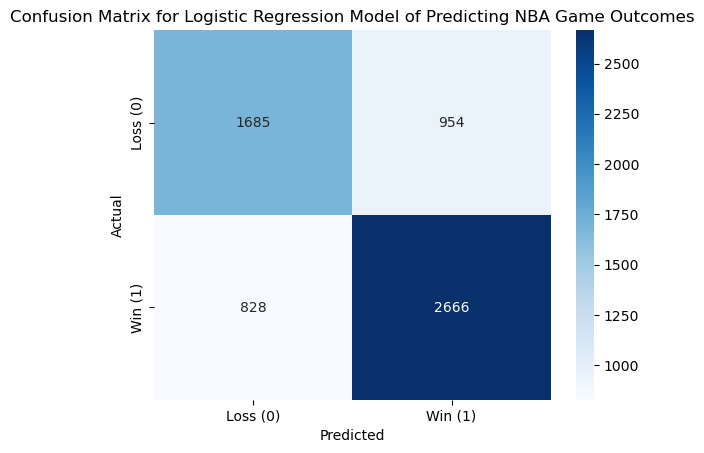

In [13]:
# create correlation matrix and heatmap
cm = confusion_matrix(y_test, y_pred, labels=[0,1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Loss (0)', 'Win (1)'],
    yticklabels=['Loss (0)', 'Win (1)'])

# predicted values on x axis, actual values on y axis
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression Model of Predicting NBA Game Outcomes')

plt.show()